Твоя задача с помощью Data Science предсказать заболевание паркинсона на ранней стадии, используя алгоритм машинного обучения XGBoost и библиотеку sklearn для нормализации признаков. Как это сделать? Тебя  придется самостоятельно изучить данный вопрос.

Используй следующий [датасет UCI ML Parkinsons](https://storage.yandexcloud.net/academy.ai/practica/parkinsons.data). Описание признаков и меток датасета представлены [здесь](https://storage.yandexcloud.net/academy.ai/practica/parkinsons.names). От тебя  требуется помимо создания самой модели получить ее точность на тестовой выборке. Выборки делить в соотношении 80% обучающая, 20% - тестовая.

Дополнительные баллы ты получишь, если сможешь получить точность более 95%.

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# 1. Загрузка данных
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
data = pd.read_csv(url)

In [37]:
# 2. Разделение признаков и меток
X = data.drop(columns=['status', 'name'])  # Признаки
y = data['status']  # Целевая переменная

In [38]:
# 3. Нормализация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
# 4. Балансировка классов с использованием SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [40]:
# 5. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [41]:
# 6. Модель XGBoost
model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

In [42]:
# 7. Оптимизация гиперпараметров с помощью GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Лучшие параметры
best_params = grid_search.best_params_
print(f"Лучшие параметры: {best_params}")

Лучшие параметры: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}


In [43]:
# 8. Обучение модели с оптимальными параметрами
best_model = grid_search.best_estimator_

In [44]:
# 9. Кросс-валидация
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Средняя точность по кросс-валидации: {np.mean(cv_scores) * 100:.2f}%")

Средняя точность по кросс-валидации: 93.62%


In [45]:
# 10. Предсказания на тестовых данных
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

In [47]:
# 11. Оценка модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Точность модели: {accuracy * 100:.2f}%")
print(f"ROC-AUC: {roc_auc:.2f}")

# Отчет по классификации
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred))

Точность модели: 100.00%
ROC-AUC: 1.00

Отчет по классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        29

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59



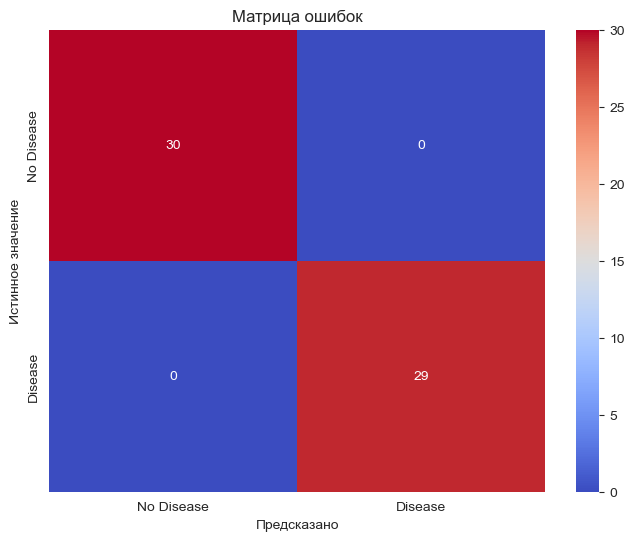

In [48]:
# 12. Матрица ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Предсказано')
plt.ylabel('Истинное значение')
plt.title('Матрица ошибок')
plt.show()

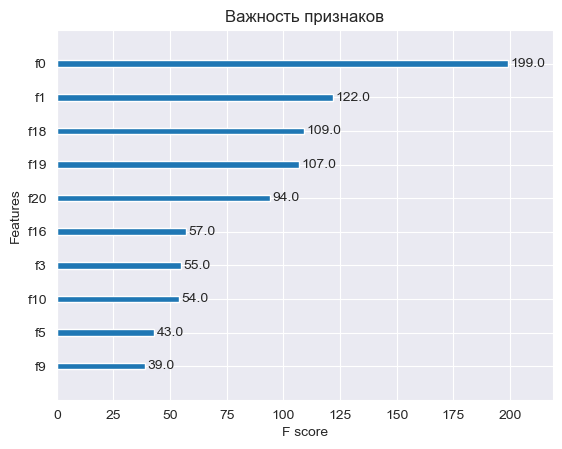

In [49]:
# 13. Важность признаков
xgb.plot_importance(best_model, max_num_features=10)
plt.title("Важность признаков")
plt.show()